# Outline
1. Imports
2. Open matchup
3. Retrieve Feature Correlations
4. Retrieve feature correlation with CHLOROPHYLL
5. Implement RF Model on ALL features
6. Permutation importance from above model run
7. Feature scatter plot
8. RF run on limited features

In [1]:
""" 
Imports
"""
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [2]:
""" 

Open matchups

"""

# matchup_df_filtered = gpd.read_parquet("MATCHUPS/data.matchups_NC")
# matchup_df_filtered = gpd.read_parquet("MATCHUPS/data.CORRECTBINNINGmatchups_NC")
# matchup_df_filtered = gpd.read_parquet("MATCHUPS/data.CORRECTBINNING_1k_matchups_NC")
# matchup_df_filtered = gpd.read_parquet("MATCHUPS/data.CORRECTBINNING_2k_matchups_NC")

# LATEST ITERATIONS/IMPROVEMENTS
# matchup_df_filtered = gpd.read_parquet("MATCHUPS/data.CORRECTBINNING_2k_nearest_matchups_NC")
# matchup_df = gpd.read_parquet("MATCHUPS/data.CORRECTBINNING_2k_nearest_matchups_NC_INPASSIVEGAPS")
matchup_df_filtered = gpd.read_parquet("MATCHUPS/data.CORRECTBINNING_1k_nearest_matchups_NC")
matchup_df = gpd.read_parquet("MATCHUPS/data.CORRECTBINNING_1k_nearest_matchups_NC_INPASSIVEGAPS")

In [3]:
""" Preliminary run on all features """

matchup_df_filtered["log_R_sw"] = np.log10(matchup_df_filtered["R_sw"])
matchup_df_filtered["D75/D25"] = matchup_df_filtered["D75"] / matchup_df_filtered["D25"]
matchup_df_filtered["log_chl_a"] = np.log10(matchup_df_filtered["chl_a"])


features = [
    'D10', 'D25', 'D50', 'D75', 'D90', 'N_surface',
    'N_subsurface', 'log_R_sw',
    'z_max', 'mean_depth', 'std_of_depth',
    'skewness', 'kurtosis', 'D75/D25'
]

X = matchup_df_filtered[features]
y = matchup_df_filtered["log_chl_a"]

#split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# train RF:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf.fit(X_train, y_train)

""". 

Get score

"""

from sklearn.metrics import r2_score

y_pred = rf.predict(X_test)

print("R²:", r2_score(y_test, y_pred))


R²: 0.7103163185761594


D75/D25         0.278253
z_max           0.139948
std_of_depth    0.115192
log_R_sw        0.083990
D50             0.059853
N_subsurface    0.057467
N_surface       0.044434
D25             0.042325
D10             0.036937
kurtosis        0.034271
D75             0.031585
D90             0.029115
skewness        0.026686
mean_depth      0.019943
dtype: float64


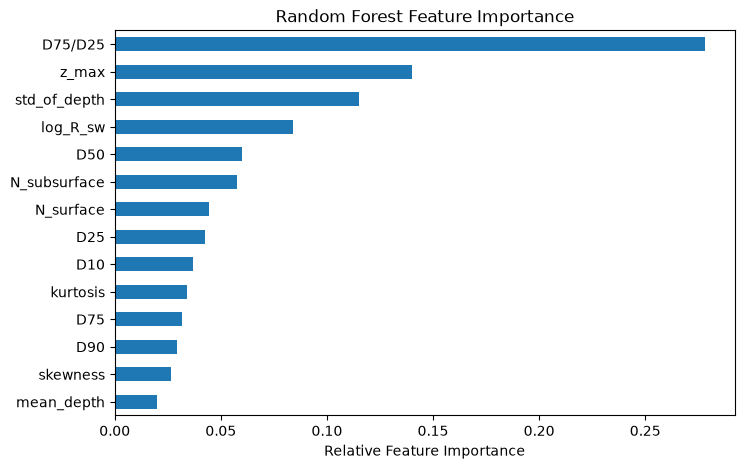

In [4]:
""" Determine the relative importance of each feature in partitioning"""
# Feature importance from the random forest
feature_importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

# Plot
feature_importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.xlabel("Relative Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()

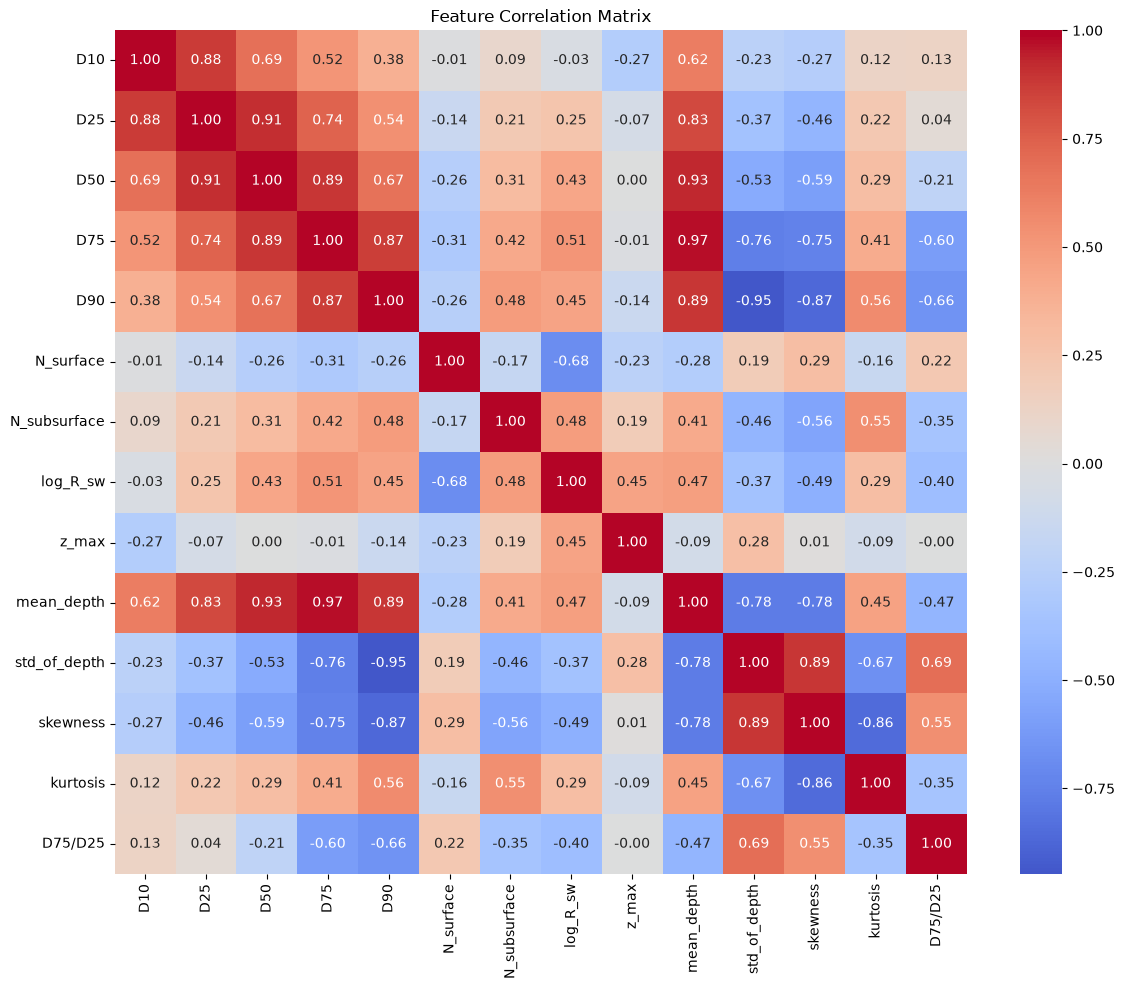

In [5]:
# """ 

# Correlation: an exploration (not used directly, just to make sure i dont choose overly-correlated input features)

# """

import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = matchup_df_filtered[features].corr()

# Plot heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Highly correlated pairs:
('D10', 'D25', np.float64(0.8763619848791651))
('D25', 'D50', np.float64(0.9111478584300224))
('D25', 'mean_depth', np.float64(0.8256415248741843))
('D50', 'D75', np.float64(0.8872093811338289))
('D50', 'mean_depth', np.float64(0.931369627211905))
('D75', 'D90', np.float64(0.8667835609387761))
('D75', 'mean_depth', np.float64(0.9731954984449425))
('D75', 'std_of_depth', np.float64(-0.7631234228981791))
('D90', 'mean_depth', np.float64(0.8861146688808917))
('D90', 'std_of_depth', np.float64(-0.9481545111249551))
('D90', 'skewness', np.float64(-0.8707757499275177))
('mean_depth', 'std_of_depth', np.float64(-0.7787523518916522))
('mean_depth', 'skewness', np.float64(-0.7803642770993634))
('std_of_depth', 'skewness', np.float64(0.8885920263898176))
('skewness', 'kurtosis', np.float64(-0.8562804555928308))
Removed D10 (correlation = 0.88)
Removed D25 (correlation = 0.91)
Removed mean_depth (correlation = 0.83)
Removed D75 (correlation = 0.89)
Removed D90 (correlatio

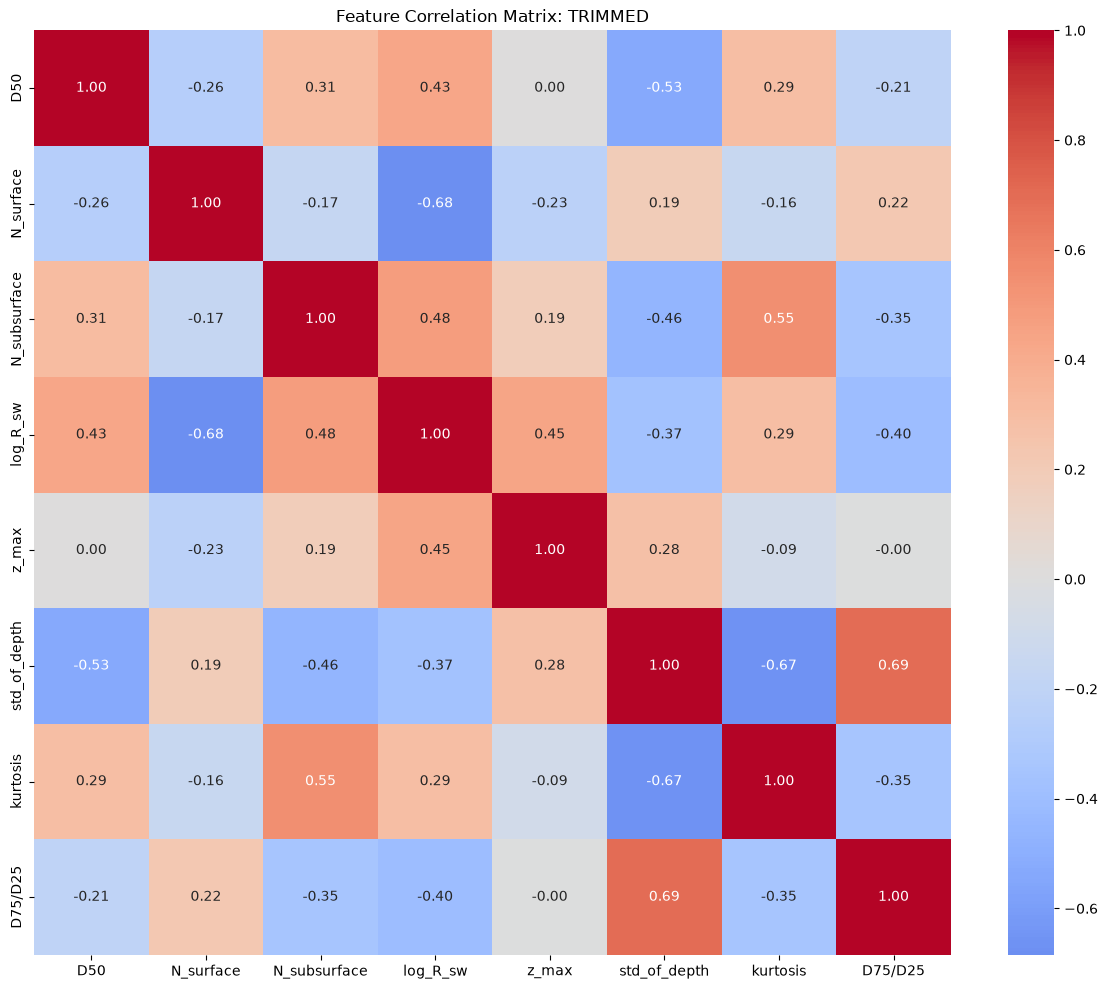

In [6]:
""" Systematically trimmed features from the dataset by comparing pairs of 
features with a correlation greater than 0.75 or less than -0.75, and removing 
the feature with the lesser importance from the dataset"""

# find highly correlated pairs
import numpy as np

corr_matrix = matchup_df_filtered[features].corr()

# Find pairs with |correlation| > 0.75
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        
        if abs(corr_value) > 0.75:
            high_corr_pairs.append(
                (
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_value
                )
            )

print("Highly correlated pairs:")
for pair in high_corr_pairs:
    print(pair)

    features_trimmed = features.copy()

for feat1, feat2, corr in high_corr_pairs:
    
    # Compare importance
    if feature_importance[feat1] < feature_importance[feat2]:
        remove = feat1
    else:
        remove = feat2
    
    if remove in features_trimmed:
        features_trimmed.remove(remove)
        print(f"Removed {remove} (correlation = {corr:.2f})")

print("\nRemaining features:")
print(features_trimmed)

# Calculate correlation matrix
corr_matrix = matchup_df_filtered[features_trimmed].corr()

# Plot heatmap
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix: TRIMMED")
plt.tight_layout()
plt.show()


In [7]:
## retrain on optimal!
X_trimmed = matchup_df_filtered[features_trimmed]

X_train, X_test, y_train, y_test = train_test_split(
    X_trimmed,
    y,
    test_size=0.2,
    random_state=42
)

rf_trimmed = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf_trimmed.fit(X_train, y_train)

y_pred = rf_trimmed.predict(X_test)

print("R² after trimming:", r2_score(y_test, y_pred))

R² after trimming: 0.7094001682850437


0.8428434880789081
0.0


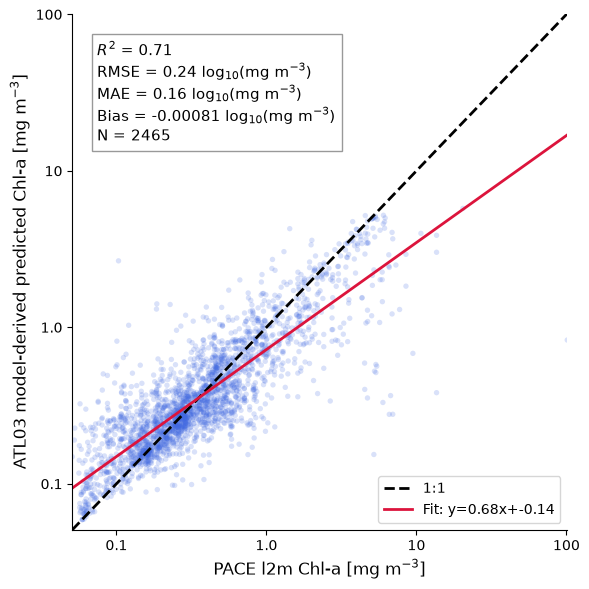

In [8]:
"""
Plot Chl vs Chl with real-value axis tick labels
"""

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Metrics (calculated in log10 space)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)


from scipy.stats import pearsonr

# Pearson correlation (calculated in log10 space)
corr, p_value = pearsonr(y_test, y_pred)
print(corr)
print(p_value)
# Plot
fig, ax = plt.subplots(figsize=(6, 6))
bias = np.mean(y_pred - y_test)
# Limits in log10 space
lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

# 1:1 line
ax.plot(
    lims, lims,
    '--',
    color='black',
    linewidth=2,
    label="1:1"
)

# Scatter (log-transformed values)
ax.scatter(
    y_test,
    y_pred,
    s=15,
    alpha=0.2,
    edgecolor="none",
    color="royalblue"
)

coef = np.polyfit(y_test, y_pred, 1)
xfit = np.linspace(*lims, 100)
ax.plot(
    xfit,
    coef[0]*xfit + coef[1],
    color="crimson",
    linewidth=2,
    label=f"Fit: y={coef[0]:.2f}x+{coef[1]:.2f}"
)


# Labels
ax.set_xlabel("PACE l2m Chl-a [mg m$^{-3}$]", fontsize=12)
ax.set_ylabel("ATL03 model-derived predicted Chl-a [mg m$^{-3}$]", fontsize=12)

# Set axis ticks in log space, but label them as real values
tick_values = np.array([0.01, 0.1, 1, 10, 100])
tick_positions = np.log10(tick_values)

ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)

ax.spines[['top', 'right']].set_visible(False)

ax.set_xticklabels(["0.01", "0.1", "1.0", "10", "100"])
ax.set_yticklabels(["0.01", "0.1", "1.0", "10", "100"])

# Metrics box
ax.text(
    0.05, 0.95,
    f"$R^2$ = {r2:.2f}\n"
    f"RMSE = {rmse:.2f} log$_{{10}}$(mg m$^{{-3}}$)\n"
    f"MAE = {mae:.2f} log$_{{10}}$(mg m$^{{-3}}$)\n"
    f"Bias = {bias:.5f} log$_{{10}}$(mg m$^{{-3}}$)\n"
    f"N = {len(y_test)}",
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.legend()

plt.tight_layout()
plt.savefig(
    "FINAL_FIGS/2kmNC_NN.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()


0.8428434880789081
0.0
Removed 124 points from plot only


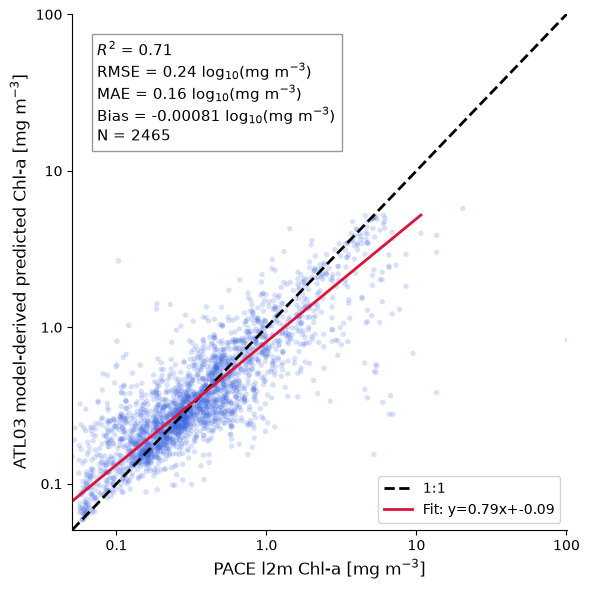

In [9]:
""" OUTLIERS REMOVED:  Not final"""
"""
Plot Chl vs Chl with real-value axis tick labels
"""

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Metrics (calculated in log10 space)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)


from scipy.stats import pearsonr

# Pearson correlation (calculated in log10 space)
corr, p_value = pearsonr(y_test, y_pred)
print(corr)
print(p_value)
# Plot
fig, ax = plt.subplots(figsize=(6, 6))
bias = np.mean(y_pred - y_test)
# Limits in log10 space
lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

# 1:1 line
ax.plot(
    lims, lims,
    '--',
    color='black',
    linewidth=2,
    label="1:1"
)


# Remove extreme plot outliers only
plot_residuals = y_pred - y_test

threshold = np.percentile(np.abs(plot_residuals), 95)
plot_mask = np.abs(plot_residuals) < threshold # adjust threshold as needed

y_test_plot = y_test[plot_mask]
y_pred_plot = y_pred[plot_mask]

print(f"Removed {np.sum(~plot_mask)} points from plot only")
# Scatter (log-transformed values)
ax.scatter(
    y_test,
    y_pred,
    s=15,
    alpha=0.2,
    edgecolor="none",
    color="royalblue"
)

coef = np.polyfit(y_test_plot, y_pred_plot, 1)
xfit = np.linspace(y_test_plot.min(), y_test_plot.max(), 100)

ax.plot(
    xfit,
    coef[0]*xfit + coef[1],
    color="crimson",
    linewidth=2,
    label=f"Fit: y={coef[0]:.2f}x+{coef[1]:.2f}"
)

# Labels
ax.set_xlabel("PACE l2m Chl-a [mg m$^{-3}$]", fontsize=12)
ax.set_ylabel("ATL03 model-derived predicted Chl-a [mg m$^{-3}$]", fontsize=12)

# Set axis ticks in log space, but label them as real values
tick_values = np.array([0.01, 0.1, 1, 10, 100])
tick_positions = np.log10(tick_values)

ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)

ax.spines[['top', 'right']].set_visible(False)

ax.set_xticklabels(["0.01", "0.1", "1.0", "10", "100"])
ax.set_yticklabels(["0.01", "0.1", "1.0", "10", "100"])

# Metrics box
ax.text(
    0.05, 0.95,
    f"$R^2$ = {r2:.2f}\n"
    f"RMSE = {rmse:.2f} log$_{{10}}$(mg m$^{{-3}}$)\n"
    f"MAE = {mae:.2f} log$_{{10}}$(mg m$^{{-3}}$)\n"
    f"Bias = {bias:.5f} log$_{{10}}$(mg m$^{{-3}}$)\n"
    f"N = {len(y_test)}",
    transform=ax.transAxes,
    va="top",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.legend()

plt.tight_layout()
# plt.savefig(
#     "FINAL_FIGS/2kmNC_NN.png",
#     dpi=600,
#     bbox_inches="tight",
#     facecolor="white"
# )
plt.show()


In [10]:
""" 

Grid L2m data

"""

# Via: https://nasa.github.io/oceandata-notebooks/notebooks/oci/subsetting_with_harmony-py.html
from aux_fx import grid_data

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Note. the following will be made into a function before Githubbing, but it is late rn

/var/folders/f5/7f8tj3d949d8x60zh8cbkqfr0000gn/T/ipykernel_18805/983027218.py:104: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(gridded_list, dim="swath")


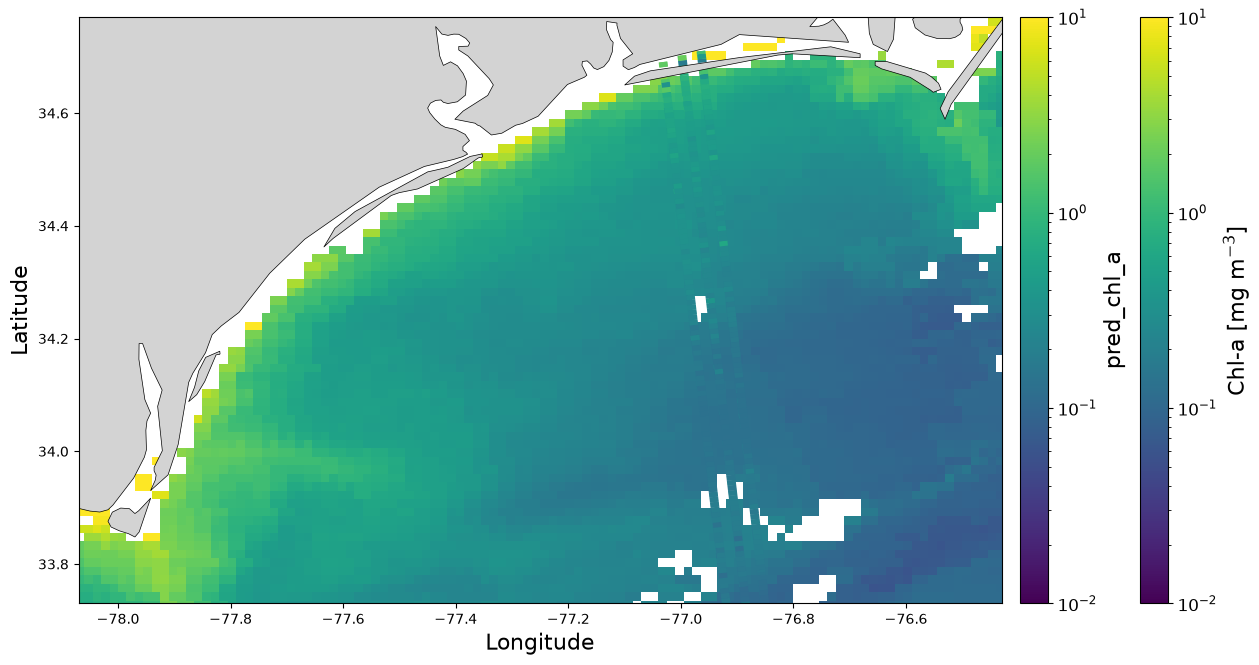

In [11]:
"""" MAP CHL under LIDAR Chl 


SAME COLOR MAP

"""
matchup_df["log_R_sw"] = np.log10(matchup_df["R_sw"])
matchup_df["D75/D25"] = matchup_df["D75"] / matchup_df["D25"]
matchup_df["log_chl_a"] = np.log10(matchup_df["chl_a"])

# Predict log10(chl-a) for EVERY LIDAR POINT. not just for matchups since the point is to fill gaps :)
matchup_df["pred_log_chl_a"] = rf_trimmed.predict(
    matchup_df[features_trimmed]
)

matchup_df["pred_chl_a"] = 10 ** matchup_df["pred_log_chl_a"]



from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import matplotlib.colors as colors
import glob
import xarray as xr
resolution = (0.015, 0.015)
ten_most_dates = ["2024-06-29"]

pLAT_MIN = 33.70
pLAT_MAX = 34.80
pLON_MIN = -78.10
pLON_MAX = -76.40

xlim = ([pLON_MIN + resolution[0], pLON_MAX - resolution[0]])
ylim = ([pLAT_MIN + resolution[1], pLAT_MAX - resolution[1]])
dict_date_files = {}

for date_str in ten_most_dates:
    # Convert to timestamp to do safe calendar math
    current_date = pd.to_datetime(date_str)
    pre_date_dt = current_date - pd.Timedelta(days=1)
    post_date_dt = current_date + pd.Timedelta(days=1)
    
    # Format them back to strings matching the PACE file naming system (YYYYMMDD)
    date_pace = current_date.strftime("%Y%m%d")
    pre_pace  = pre_date_dt.strftime("%Y%m%d")
    post_pace = post_date_dt.strftime("%Y%m%d")

    patterns = [
        f"DATA/PACE_l2_NC/*{date_pace}*.nc",
        f"DATA/PACE_l2_NC/*{pre_pace}T1[2-9]*.nc",
        f"DATA/PACE_l2_NC/*{pre_pace}T2[0-4]*.nc",
        f"DATA/PACE_l2_NC/*{post_pace}T0[0-9]*.nc",
        f"DATA/PACE_l2_NC/*{post_pace}T1[0-2]*.nc"
    ]
    
    matched_files = []
    for pattern in patterns:
        matched_files.extend(glob.glob(pattern))
        
    dict_date_files[date_str] = matched_files



fig, ax = plt.subplots(
    figsize=(10, 8),
    constrained_layout=True
)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

i = 0
for date_key in dict_date_files:
    axis = ax

    gridded_list = []

    for file in dict_date_files[date_key]:
        dt = xr.open_datatree(file)
        ds = xr.merge(dt.to_dict().values())
        ds = ds.set_coords(("longitude", "latitude"))

        ds_gridded = grid_data(ds, resolution)

        # Drop the original swath dimensions so xarray won't try to align them
        dims_to_drop = [d for d in ["number_of_lines", "pixels_per_line"] if d in ds_gridded.dims]
        coords_to_drop = [c for c in ["number_of_lines", "pixels_per_line"] if c in ds_gridded.coords]
        
        ds_gridded = ds_gridded.drop_dims(dims_to_drop).drop_vars(coords_to_drop, errors="ignore")

        gridded_list.append(ds_gridded)

    combined = xr.concat(gridded_list, dim="swath")
    ds_gridded = combined.mean(dim="swath", skipna=True)

    chl_norm = LogNorm(vmin=0.01, vmax=10.0)
    im = ds_gridded["chlor_a"].plot(
        ax=axis,
        cmap="viridis",
        norm=chl_norm,
        add_colorbar=False,
    )

    # LIDAR overlay
    df_day_segments = matchup_df[
        pd.to_datetime(matchup_df['lidar_date']).dt.strftime("%Y-%m-%d") == date_key
    ]

    # vmin = matchup_df_filtered["pred_log_chl_a"].min()
    # vmax = matchup_df_filtered["pred_log_chl_a"].max()

    # kurt_norm = colors.Normalize(vmin=vmin, vmax=vmax)
    if len(df_day_segments) > 0:
        df_day_segments.plot(
        ax=axis,
        column="pred_chl_a",
        cmap="viridis",
        linewidth=6,
        norm=chl_norm,
        legend=False,
    )

    

    land = gpd.read_file("ne_10m_land.shp")
    land = land.to_crs(epsg=4326)
    land.plot(ax=axis, facecolor="lightgray", edgecolor="black", linewidth=0.5, zorder=2)

    # --- inset colorbars: fixed absolute size, independent of map aspect ratio ---
    cax1 = inset_axes(
        axis, width="3%", height="100%",     # width/height as % of the PARENT axes bbox
        loc="center left",
        bbox_to_anchor=(1.02, 0.0, 1, 1),  # push it just right of the map
        bbox_transform=axis.transAxes,
        borderpad=0,
    )
    cb1 = fig.colorbar(cm.ScalarMappable(norm=chl_norm, cmap="viridis"), cax=cax1)
    cb1.set_label("pred_chl_a")

    cax2 = inset_axes(
        axis, width="3%", height="100%",
        loc="center left",
        bbox_to_anchor=(1.15, 0.0, 1, 1),  # further right, next to cax1
        bbox_transform=axis.transAxes,
        borderpad=0,
    )

    cb2 = fig.colorbar(cm.ScalarMappable(norm=chl_norm, cmap="viridis"), cax=cax2)
    cb2.set_label("Chl-a [mg m$^{-3}$]")

    axis.set_xlim([xlim[0] + resolution[0], xlim[1] - resolution[0]])
    axis.set_ylim([ylim[0] + resolution[1], ylim[1] - resolution[1]])
    # axis.set_title(date_key + dict_date_files[date_key][0])
    axis.set_title("")
    axis.set_xlabel("Longitude", fontsize=16)
    axis.set_ylabel("Latitude", fontsize=16)
    i = i+1



fig.canvas.draw()

bbox = fig.get_tightbbox(fig.canvas.get_renderer())

# fig.savefig(
#     "FINAL_FIGS/ChlvCHL_DIFFCM.png",
#     dpi=600,
#     bbox_inches=bbox,
#     facecolor="white"
# )


fig.savefig(
    "FINAL_FIGS/ChlvCHL_SAMECM.png",
    dpi=600,
    bbox_inches=bbox,
    facecolor="white"
)

plt.show()



/var/folders/f5/7f8tj3d949d8x60zh8cbkqfr0000gn/T/ipykernel_18805/1638582644.py:92: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(gridded_list, dim="swath")


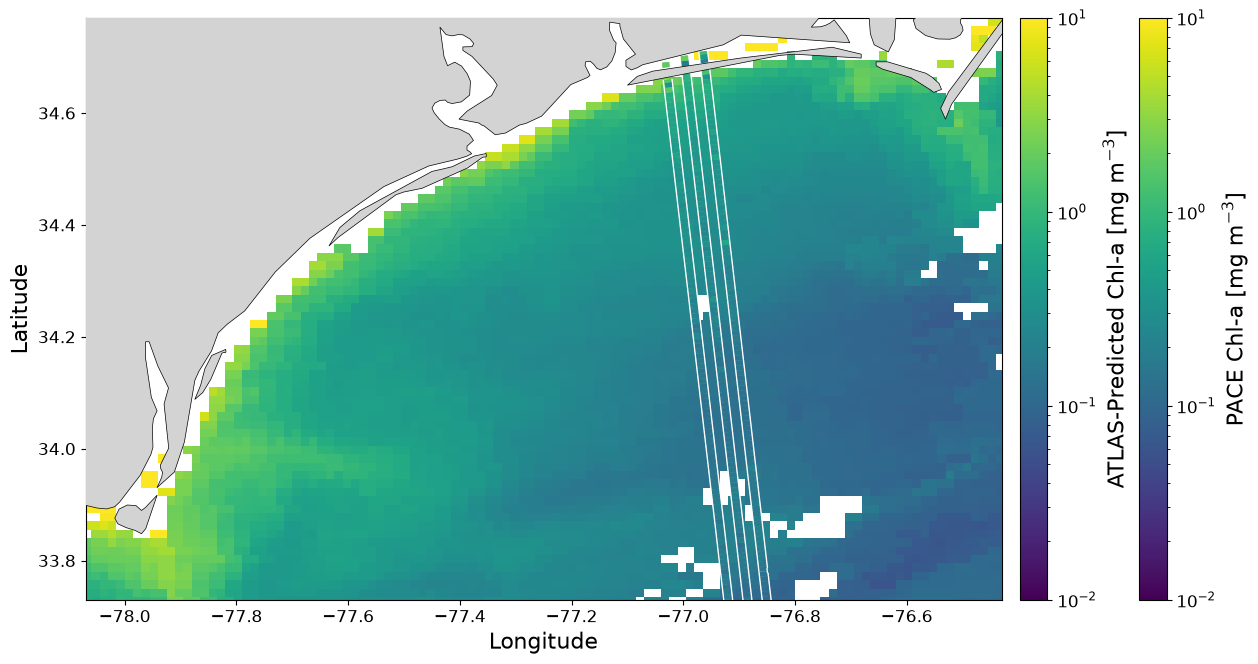

In [12]:
"""" MAP CHL under LIDAR Chl. white outline """

# Predict log10(chl-a) for EVERY LIDAR POINT
matchup_df["pred_log_chl_a"] = rf_trimmed.predict(
    matchup_df[features_trimmed]
)

matchup_df["pred_chl_a"] = 10 ** matchup_df["pred_log_chl_a"]



from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import matplotlib.colors as colors
import glob
import xarray as xr
resolution = (0.015, 0.015)
ten_most_dates = ["2024-06-29"]

pLAT_MIN = 33.70
pLAT_MAX = 34.80
pLON_MIN = -78.10
pLON_MAX = -76.40

xlim = ([pLON_MIN + resolution[0], pLON_MAX - resolution[0]])
ylim = ([pLAT_MIN + resolution[1], pLAT_MAX - resolution[1]])

dict_date_files = {}

for date_str in ten_most_dates:
    current_date = pd.to_datetime(date_str)
    pre_date_dt = current_date - pd.Timedelta(days=1)
    post_date_dt = current_date + pd.Timedelta(days=1)
    
    date_pace = current_date.strftime("%Y%m%d")
    pre_pace  = pre_date_dt.strftime("%Y%m%d")
    post_pace = post_date_dt.strftime("%Y%m%d")

    patterns = [
        f"DATA/PACE_l2_NC/*{date_pace}*.nc",
        f"DATA/PACE_l2_NC/*{pre_pace}T1[2-9]*.nc",
        f"DATA/PACE_l2_NC/*{pre_pace}T2[0-4]*.nc",
        f"DATA/PACE_l2_NC/*{post_pace}T0[0-9]*.nc",
        f"DATA/PACE_l2_NC/*{post_pace}T1[0-2]*.nc"
    ]
    
    matched_files = []
    for pattern in patterns:
        matched_files.extend(glob.glob(pattern))
        
    dict_date_files[date_str] = matched_files


fig, ax = plt.subplots(
    figsize=(10, 8),
    constrained_layout=True
)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

for date_key in dict_date_files:
    axis = ax

    gridded_list = []

    for file in dict_date_files[date_key]:
        dt = xr.open_datatree(file)
        ds = xr.merge(dt.to_dict().values())
        ds = ds.set_coords(("longitude", "latitude"))

        ds_gridded = grid_data(ds, resolution)

        dims_to_drop = [d for d in ["number_of_lines", "pixels_per_line"] if d in ds_gridded.dims]
        coords_to_drop = [c for c in ["number_of_lines", "pixels_per_line"] if c in ds_gridded.coords]
        
        ds_gridded = ds_gridded.drop_dims(dims_to_drop).drop_vars(coords_to_drop, errors="ignore")

        gridded_list.append(ds_gridded)

    combined = xr.concat(gridded_list, dim="swath")
    ds_gridded = combined.mean(dim="swath", skipna=True)

    chl_norm = LogNorm(vmin=0.01, vmax=10.0)

    im = ds_gridded["chlor_a"].plot(
        ax=axis,
        cmap="viridis",
        norm=chl_norm,
        add_colorbar=False,
    )

    # LIDAR predicted CHL overlay
    df_day_segments = matchup_df[
        pd.to_datetime(matchup_df['lidar_date']).dt.strftime("%Y-%m-%d") == date_key
    ]

    if len(df_day_segments) > 0:
        # LIDAR track outline
        df_day_segments.plot(
            ax=axis,
            color="white",
            linewidth=7,
            zorder=3,
        )

        # LIDAR track colored by predicted chl-a
        df_day_segments.plot(
            ax=axis,
            column="pred_chl_a",
            cmap="viridis",
            linewidth=5,
            norm=chl_norm,
            legend=False,
            zorder=4,
        )

    land = gpd.read_file("ne_10m_land.shp")
    land = land.to_crs(epsg=4326)
    land.plot(
        ax=axis,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.5,
        zorder=5
    )

    cax1 = inset_axes(
        axis,
        width="3%",
        height="100%",
        loc="center left",
        bbox_to_anchor=(1.02, 0.0, 1, 1),
        bbox_transform=axis.transAxes,
        borderpad=0,
    )

    cb1 = fig.colorbar(
        cm.ScalarMappable(norm=chl_norm, cmap="viridis"),
        cax=cax1
    )
    cb1.set_label("ATLAS-Predicted Chl-a [mg m$^{-3}$]")

    cax2 = inset_axes(
        axis,
        width="3%",
        height="100%",
        loc="center left",
        bbox_to_anchor=(1.15, 0.0, 1, 1),
        bbox_transform=axis.transAxes,
        borderpad=0,
    )

    cb2 = fig.colorbar(
        cm.ScalarMappable(norm=chl_norm, cmap="viridis"),
        cax=cax2
    )
    cb2.set_label("PACE Chl-a [mg m$^{-3}$]")

    axis.set_xlim([xlim[0] + resolution[0], xlim[1] - resolution[0]])
    axis.set_ylim([ylim[0] + resolution[1], ylim[1] - resolution[1]])
    axis.set_title("")
    axis.set_xlabel("Longitude", fontsize=16)
    axis.set_ylabel("Latitude", fontsize=16)


fig.canvas.draw()

bbox = fig.get_tightbbox(fig.canvas.get_renderer())

# fig.savefig(
#     "FINAL_FIGS/ChlvCHLNC_SAMECM.png",
#     dpi=600,
#     bbox_inches="tight",
#     pad_inches=0.2,
#     facecolor="white"
# )

fig.savefig(
    "FINAL_FIGS/ChlvCHLNC_SAMECM_oline.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.2,
    facecolor="white"
)

plt.show()

/var/folders/f5/7f8tj3d949d8x60zh8cbkqfr0000gn/T/ipykernel_18805/2587121896.py:100: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(gridded_list, dim="swath")


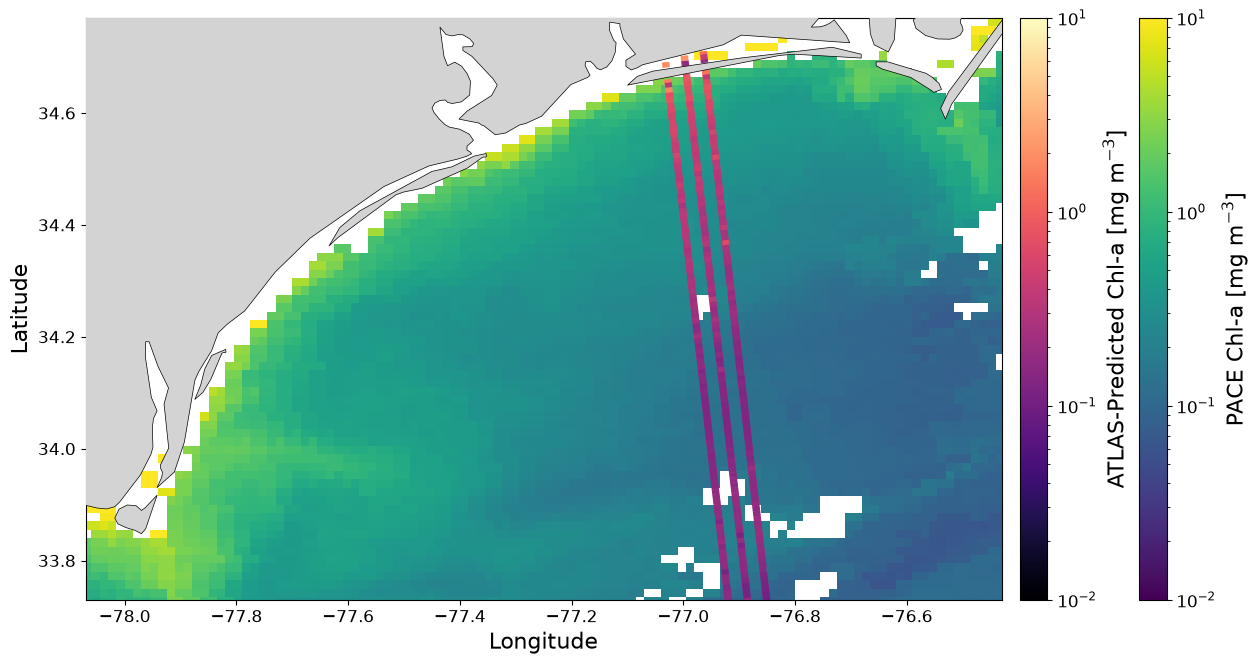

In [13]:
"""" MAP CHL under LIDAR Chl. magma """

# Predict log10(chl-a) for every matchup
# matchup_df_filtered["pred_log_chl_a"] = rf.predict(
#     matchup_df_filtered[features_A]
# )

# matchup_df_filtered["pred_chl_a"] = 10 ** matchup_df_filtered["pred_log_chl_a"]

# df_day_segments = matchup_df_filtered[matchup_df_filtered['lidar_date'] == "2024-06-29"]

# Predict log10(chl-a) for EVERY LIDAR POINT
matchup_df["pred_log_chl_a"] = rf_trimmed.predict(
    matchup_df[features_trimmed]
)

matchup_df["pred_chl_a"] = 10 ** matchup_df["pred_log_chl_a"]



from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.cm as cm
import matplotlib.colors as colors
import glob
import xarray as xr
resolution = (0.015, 0.015)
ten_most_dates = ["2024-06-29"]

pLAT_MIN = 33.70
pLAT_MAX = 34.80
pLON_MIN = -78.10
pLON_MAX = -76.40

xlim = ([pLON_MIN + resolution[0], pLON_MAX - resolution[0]])
ylim = ([pLAT_MIN + resolution[1], pLAT_MAX - resolution[1]])
dict_date_files = {}

for date_str in ten_most_dates:
    current_date = pd.to_datetime(date_str)
    pre_date_dt = current_date - pd.Timedelta(days=1)
    post_date_dt = current_date + pd.Timedelta(days=1)
    
    date_pace = current_date.strftime("%Y%m%d")
    pre_pace  = pre_date_dt.strftime("%Y%m%d")
    post_pace = post_date_dt.strftime("%Y%m%d")

    patterns = [
        f"DATA/PACE_l2_NC/*{date_pace}*.nc",
        f"DATA/PACE_l2_NC/*{pre_pace}T1[2-9]*.nc",
        f"DATA/PACE_l2_NC/*{pre_pace}T2[0-4]*.nc",
        f"DATA/PACE_l2_NC/*{post_pace}T0[0-9]*.nc",
        f"DATA/PACE_l2_NC/*{post_pace}T1[0-2]*.nc"
    ]
    
    matched_files = []
    for pattern in patterns:
        matched_files.extend(glob.glob(pattern))
        
    dict_date_files[date_str] = matched_files


fig, ax = plt.subplots(
    figsize=(10, 8),
    constrained_layout=True
)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

for date_key in dict_date_files:
    axis = ax

    gridded_list = []

    for file in dict_date_files[date_key]:
        dt = xr.open_datatree(file)
        ds = xr.merge(dt.to_dict().values())
        ds = ds.set_coords(("longitude", "latitude"))

        ds_gridded = grid_data(ds, resolution)

        dims_to_drop = [d for d in ["number_of_lines", "pixels_per_line"] if d in ds_gridded.dims]
        coords_to_drop = [c for c in ["number_of_lines", "pixels_per_line"] if c in ds_gridded.coords]
        
        ds_gridded = ds_gridded.drop_dims(dims_to_drop).drop_vars(coords_to_drop, errors="ignore")

        gridded_list.append(ds_gridded)

    combined = xr.concat(gridded_list, dim="swath")
    ds_gridded = combined.mean(dim="swath", skipna=True)

    chl_norm = LogNorm(vmin=0.01, vmax=10.0)

    im = ds_gridded["chlor_a"].plot(
        ax=axis,
        cmap="viridis",
        norm=chl_norm,
        add_colorbar=False,
    )

    # LIDAR predicted CHL overlay
    df_day_segments = matchup_df[
        pd.to_datetime(matchup_df['lidar_date']).dt.strftime("%Y-%m-%d") == date_key
    ]

    if len(df_day_segments) > 0:
        # # LIDAR track outline
        # df_day_segments.plot(
        #     ax=axis,
        #     color="white",
        #     linewidth=9,
        #     zorder=3,
        # )

        # LIDAR track colored by predicted chl-a
        df_day_segments.plot(
            ax=axis,
            column="pred_chl_a",
            cmap="magma",
            linewidth=5,
            norm=chl_norm,
            legend=False,
            zorder=4,
        )

    land = gpd.read_file("ne_10m_land.shp")
    land = land.to_crs(epsg=4326)
    land.plot(
        ax=axis,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.5,
        zorder=5
    )

    cax1 = inset_axes(
        axis,
        width="3%",
        height="100%",
        loc="center left",
        bbox_to_anchor=(1.02, 0.0, 1, 1),
        bbox_transform=axis.transAxes,
        borderpad=0,
    )

    cb1 = fig.colorbar(
        cm.ScalarMappable(norm=chl_norm, cmap="magma"),
        cax=cax1
    )
    cb1.set_label("ATLAS-Predicted Chl-a [mg m$^{-3}$]")

    cax2 = inset_axes(
        axis,
        width="3%",
        height="100%",
        loc="center left",
        bbox_to_anchor=(1.15, 0.0, 1, 1),
        bbox_transform=axis.transAxes,
        borderpad=0,
    )

    cb2 = fig.colorbar(
        cm.ScalarMappable(norm=chl_norm, cmap="viridis"),
        cax=cax2
    )
    cb2.set_label("PACE Chl-a [mg m$^{-3}$]")

    axis.set_xlim([xlim[0] + resolution[0], xlim[1] - resolution[0]])
    axis.set_ylim([ylim[0] + resolution[1], ylim[1] - resolution[1]])
    axis.set_title("")
    axis.set_xlabel("Longitude", fontsize=16)
    axis.set_ylabel("Latitude", fontsize=16)


fig.canvas.draw()

bbox = fig.get_tightbbox(fig.canvas.get_renderer())

fig.savefig(
    "FINAL_FIGS/ChlvCHLNC_DIFFCM.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.2,
    facecolor="white"
)

In [14]:
# """ LINEAR SCATTER: exploratory """

# features_to_scatter = [
#     "log_R_sw",
#     "std_of_depth",
#     "D50",
#     "N_subsurface",
#     "D10",
#     "kurtosis",
#     "skewness",
#     "z_max",
#     "D75/D25"
# ]

# units = ["", "", "[m]", "", "[m]", "", "", "[m]", ""]

# corr = (
#     matchup_df_filtered[features_to_scatter + ['log_chl_a']]
#     .corr()['log_chl_a']
#     .drop('log_chl_a')
#     .sort_values(key=abs, ascending=False)
# )

# i = 0
# fig, ax = plt.subplots(3, 3, figsize=(10, 10), constrained_layout=True)
# for row in ax:
#     for axis in row:
#         y = matchup_df_filtered['log_chl_a']
#         x = matchup_df_filtered[features_to_scatter[i]]

#         # lims = [
#         #     max(x.max(), y.max()),
#         #     min(x.min(), y.min())
#         # ]
#         xmin, xmax = np.nanpercentile(x, [10, 90])
#         axis.set_xlim(xmin, xmax)


#         axis.scatter(
#             x, 
#             y,
#             s=15,
#             alpha=0.01,
#             edgecolor="none",
#             color="royalblue"
#         )   

#         # Consistent y-axis across all subplots
#         axis.set_ylim(np.log10([0.01, 100]))

#         axis.set_yticks(np.log10([0.01, 0.1, 1, 10, 100]))
#         axis.set_yticklabels(["0.01", "0.1", "1.0", "10", "100"])
        

#         # Labels
#         axis.set_ylabel("PACE l2m Chl-a [mg m$^{-3}$]", fontsize=8)
#         axis.set_xlabel("Feature: " + features_to_scatter[i] + " " + units[i], fontsize=8)
#         tick_values = np.array([0.01, 0.1, 1, 10, 100])
#         tick_positions = np.log10(tick_values)

#         axis.set_yticks(tick_positions)
#         axis.set_yticklabels(["0.01", "0.1", "1.0", "10", "100"])

#         # # REGRESSION
#         # x = matchup_df_filtered[features_to_scatter[i]]
#         # y = matchup_df_filtered["log_chl_a"]

#         mask = np.isfinite(x) & np.isfinite(y)

#         x_fit = x[mask]
#         y_fit = y[mask]

#         if len(x_fit) > 1 and x_fit.nunique() > 1:
#             coef = np.polyfit(x_fit, y_fit, 1)

#             xline = np.linspace(x_fit.min(), x_fit.max(), 100)
#             axis.plot(
#                 xline,
#                 coef[0] * xline + coef[1],
#                 color="crimson",
#                 linewidth=2,
#                 label=f"Fit: y={coef[0]:.2f}x+{coef[1]:.2f}"
#             )


            
#         axis.text(
#             0.05, 0.95,
#             f"Correlation = {corr[features_to_scatter[i]]:.2f}\n"
#             f"Fit: y={coef[0]:.2f}x+{coef[1]:.2f}",
#             transform=axis.transAxes,
#             va="top",
#             fontsize=11,
#             bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
#         )
        

#         i += 1

#     plt.suptitle("Feature Ensemble vs PACE Chl")
        


        

In [15]:
# """ LOG SCATTER: exploratory """

# features_to_scatter = [
#     "R_sw",
#     "std_of_depth",
#     "D50",
#     "N_subsurface",
#     "D10",
#     "kurtosis",
#     "skewness",
#     "z_max",
#     "D75/D25"
# ]

# # Create log-transformed feature columns
# log_features = []

# for feature in features_to_scatter:
#     log_feature = "log_" + feature.replace("/", "_")
    
#     matchup_df_filtered[log_feature] = np.log10(
#         matchup_df_filtered[feature].where(matchup_df_filtered[feature] > 0)
#     )
    
#     log_features.append(log_feature)

# print(log_features)


# corr = (
#     matchup_df_filtered[log_features + ['log_chl_a']]
#     .corr()['log_chl_a']
#     .drop('log_chl_a')
#     .sort_values(key=abs, ascending=False)
# )

# i = 0
# fig, ax = plt.subplots(3, 3, figsize=(10, 10), constrained_layout=True)
# for row in ax:
#     for axis in row:
#         y = matchup_df_filtered['log_chl_a']
#         x = matchup_df_filtered[log_features[i]]

#         # lims = [
#         #     max(x.max(), y.max()),
#         #     min(x.min(), y.min())
#         # ]
#         xmin, xmax = np.nanpercentile(x, [10, 90])
#         # axis.set_xlim(xmin, xmax)


#         axis.scatter(
#             x, 
#             y,
#             s=15,
#             alpha=0.01,
#             edgecolor="none",
#             color="royalblue"
#         )   

#         # Consistent y-axis across all subplots
#         axis.set_ylim(np.log10([0.01, 100]))

#         axis.set_yticks(np.log10([0.01, 0.1, 1, 10, 100]))
#         axis.set_yticklabels(["0.01", "0.1", "1.0", "10", "100"])
        

#         # Labels
#         axis.set_ylabel("PACE l2m Chl-a [mg m$^{-3}$]", fontsize=8)
#         axis.set_xlabel("Feature: " + log_features[i], fontsize=8)
#         tick_values = np.array([0.01, 0.1, 1, 10, 100])
#         tick_positions = np.log10(tick_values)

#         axis.set_yticks(tick_positions)
#         axis.set_yticklabels(["0.01", "0.1", "1.0", "10", "100"])

 

#         mask = np.isfinite(x) & np.isfinite(y)

#         x_fit = x[mask]
#         y_fit = y[mask]

#         if len(x_fit) > 1 and x_fit.nunique() > 1:
#             coef = np.polyfit(x_fit, y_fit, 1)

#             xline = np.linspace(x_fit.min(), x_fit.max(), 100)
#             axis.plot(
#                 xline,
#                 coef[0] * xline + coef[1],
#                 color="crimson",
#                 linewidth=2,
#                 label=f"Fit: y={coef[0]:.2f}x+{coef[1]:.2f}"
#             )


            
#         axis.text(
#             0.05, 0.95,
#             f"Correlation = {corr[log_features[i]]:.2f}\n"
#             f"Fit: y={coef[0]:.2f}x+{coef[1]:.2f}",
#             transform=axis.transAxes,
#             va="top",
#             fontsize=11,
#             bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
#         )
        

#         i += 1

#     plt.suptitle("Feature Ensemble vs PACE Chl")
        


        

# INDIVIDUAL SCATTER PLOTS WILL ALSO BE MADE INTO A FX, Dont worry

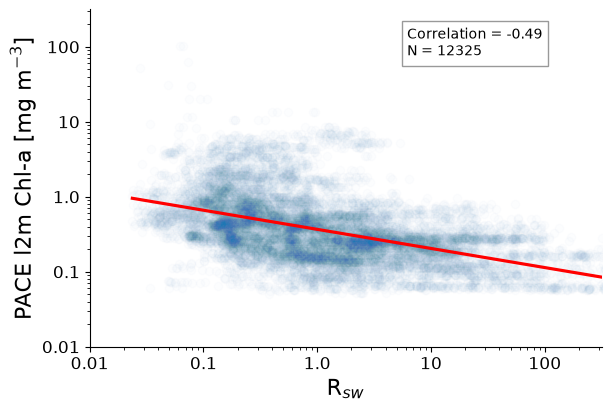

-1.6246897377612077
0.023730684326710817


In [16]:
""" 

Rsw scatter plot

"""

import matplotlib.ticker as ticker

import seaborn as sns
fig, ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans", # or Arial
    "font.size": 10,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

sns.regplot(
    data=matchup_df_filtered,
    x="log_R_sw",
    y="log_chl_a",
    scatter_kws={"alpha":0.01},
    line_kws={"color":"red"},
    truncate=True
)

ax.set_xlabel('R$_{sw}$')
ax.set_ylabel("PACE l2m Chl-a [mg m$^{-3}$]")

# Set axis ticks in log space, but label them as real values
tick_values = np.array([0.01, 0.1, 1, 10, 100])
tick_positions = np.log10(tick_values)

ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)

ax.set_xticklabels(["0.01", "0.1", "1.0", "10", "100"])
ax.set_yticklabels(["0.01", "0.1", "1.0", "10", "100"])
plt.xlim([-2, 2.5])
plt.ylim([-2, 2.5])

x = matchup_df_filtered["log_R_sw"].values
y = matchup_df_filtered["log_chl_a"].values

mask = np.isfinite(x) & np.isfinite(y)

corr, p_value = pearsonr(x[mask], y[mask])
ax.text(
    0.62, 0.95,
    f"Correlation = {corr:.2f}\n"
    f"N = {len(matchup_df_filtered["log_chl_a"])}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

# 2. Set the axis to log scale
# ax.set_xscale("log")

# 3. Turn on the mini lines (minor ticks)
ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs="auto", numticks=12))
ax.xaxis.set_minor_formatter(ticker.NullFormatter())  # Hides labels on mini lines

# 4. Optional: Draw light gridlines on those mini lines
# plt.grid(True, which="minor", color="lightgray", linestyle="--", linewidth=0.5)
# plt.grid(True, which="major", color="gray", linestyle="-", linewidth=0.8)
minor_values = []
for exponent in [-2, -1, 0, 1, 2]: # Covers decades from 0.01 up to 100
    minor_values.extend([i * (10**exponent) for i in range(2, 10)])

# Convert those real values to log10 positions to match your data
minor_positions = np.log10(minor_values)

# Apply the mini lines to BOTH X and Y axes
ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_positions))
ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_positions))

ax.tick_params(axis='x')
ax.tick_params(axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig(
    "FINAL_FIGS/PACEChl_v_Rsw.png",
    dpi=600,
    facecolor="white"
)
plt.show()
print(np.min(matchup_df_filtered['log_R_sw']))
print(np.min(matchup_df_filtered['R_sw']))

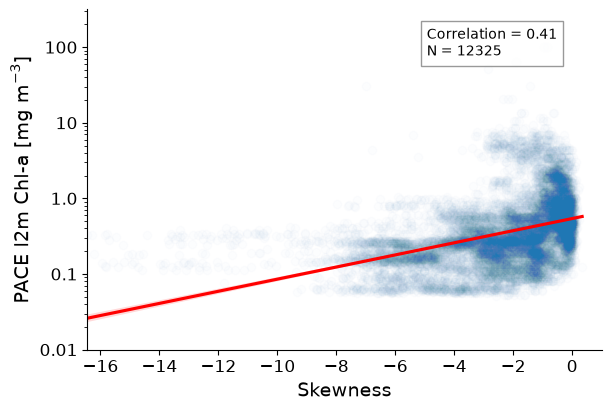

count    12325.000000
mean        -2.331254
std          2.221074
min        -16.446909
25%         -3.345973
50%         -1.695732
75%         -0.626067
max          0.338337
Name: skewness, dtype: float64


In [17]:
""" Skewness Scatter Plot """

import matplotlib.ticker as ticker

import seaborn as sns
fig, ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans", # or Arial
    "font.size": 10,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

sns.regplot(
    data=matchup_df_filtered,
    x="skewness",
    y="log_chl_a",
    scatter_kws={"alpha":0.01},
    line_kws={"color":"red"},
    truncate=True
)

ax.set_xlabel('Skewness')
ax.set_ylabel("PACE l2m Chl-a [mg m$^{-3}$]")

# Set axis ticks in log space, but label them as real values
tick_values = np.array([0.01, 0.1, 1, 10, 100])
tick_positions = np.log10(tick_values)

# ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)

# ax.set_xticklabels(["0.01", "0.1", "1.0", "10", "100"])
ax.set_yticklabels(["0.01", "0.1", "1.0", "10", "100"])
plt.ylim([-2, 2.5])
plt.xlim([np.min(matchup_df_filtered["skewness"]), 1])

x = matchup_df_filtered["skewness"].values
y = matchup_df_filtered["log_chl_a"].values

mask = np.isfinite(x) & np.isfinite(y)

corr, p_value = pearsonr(x[mask], y[mask])
ax.text(
    0.66, 0.95,
    f"Correlation = {corr:.2f}\n"
    f"N = {len(matchup_df_filtered["log_chl_a"])}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

# 2. Set the axis to log scale
# ax.set_xscale("log")

# 3. Turn on the mini lines (minor ticks)
# ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs="auto", numticks=12))
ax.xaxis.set_minor_formatter(ticker.NullFormatter())  # Hides labels on mini lines

# 4. Optional: Draw light gridlines on those mini lines
# plt.grid(True, which="minor", color="lightgray", linestyle="--", linewidth=0.5)
# plt.grid(True, which="major", color="gray", linestyle="-", linewidth=0.8)
minor_values = []
for exponent in [-2, -1, 0, 1, 2]: # Covers decades from 0.01 up to 100
    minor_values.extend([i * (10**exponent) for i in range(2, 10)])

# Convert those real values to log10 positions to match your data
minor_positions = np.log10(minor_values)

# Apply the mini lines to BOTH X and Y axes
# ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_positions))
ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_positions))
# ax.tick_params(axis='x', labelsize=12)
# ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig(
    "FINAL_FIGS/PACEChl_v_Skew.png",
    dpi=600,
    facecolor="white"
)
plt.show()
# print(np.min(matchup_df_filtered['log_R_sw']))
print(matchup_df_filtered['skewness'].describe())

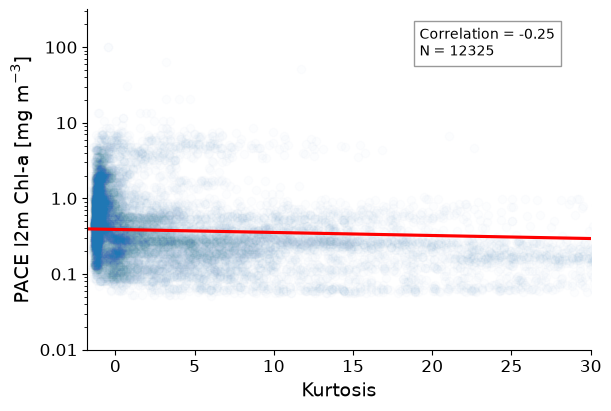

count    12325.000000
mean        10.706223
std         26.841927
min         -1.772549
25%         -0.880254
50%          1.695074
75%         10.844172
max        380.397430
Name: kurtosis, dtype: float64


In [18]:
""" Kurtosis Scatter Plot """

import matplotlib.ticker as ticker

import seaborn as sns
fig, ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans", # or Arial
    "font.size": 10,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

sns.regplot(
    data=matchup_df_filtered,
    x="kurtosis",
    y="log_chl_a",
    scatter_kws={"alpha":0.01},
    line_kws={"color":"red"},
    truncate=True
)

ax.set_xlabel('Kurtosis')
ax.set_ylabel("PACE l2m Chl-a [mg m$^{-3}$]")

# Set axis ticks in log space, but label them as real values
tick_values = np.array([0.01, 0.1, 1, 10, 100])
tick_positions = np.log10(tick_values)

# ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)

# ax.set_xticklabels(["0.01", "0.1", "1.0", "10", "100"])
ax.set_yticklabels(["0.01", "0.1", "1.0", "10", "100"])
plt.ylim([-2, 2.5])
plt.xlim([np.min(matchup_df_filtered["kurtosis"]), 30])

x = matchup_df_filtered["kurtosis"].values
y = matchup_df_filtered["log_chl_a"].values

mask = np.isfinite(x) & np.isfinite(y)

corr, p_value = pearsonr(x[mask], y[mask])
ax.text(
    0.66, 0.95,
    f"Correlation = {corr:.2f}\n"
    f"N = {len(matchup_df_filtered["log_chl_a"])}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

# 2. Set the axis to log scale
# ax.set_xscale("log")

# 3. Turn on the mini lines (minor ticks)
# ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs="auto", numticks=12))
ax.xaxis.set_minor_formatter(ticker.NullFormatter())  # Hides labels on mini lines

# 4. Optional: Draw light gridlines on those mini lines
# plt.grid(True, which="minor", color="lightgray", linestyle="--", linewidth=0.5)
# plt.grid(True, which="major", color="gray", linestyle="-", linewidth=0.8)
minor_values = []
for exponent in [-2, -1, 0, 1, 2]: # Covers decades from 0.01 up to 100
    minor_values.extend([i * (10**exponent) for i in range(2, 10)])

# Convert those real values to log10 positions to match your data
minor_positions = np.log10(minor_values)

# Apply the mini lines to BOTH X and Y axes
# ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_positions))
ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_positions))
# ax.tick_params(axis='x', labelsize=12)
# ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig(
    "FINAL_FIGS/PACEChl_v_Kurt.png",
    dpi=600,
    facecolor="white"
)
plt.show()
# print(np.min(matchup_df_filtered['log_R_sw']))
print(matchup_df_filtered['kurtosis'].describe())

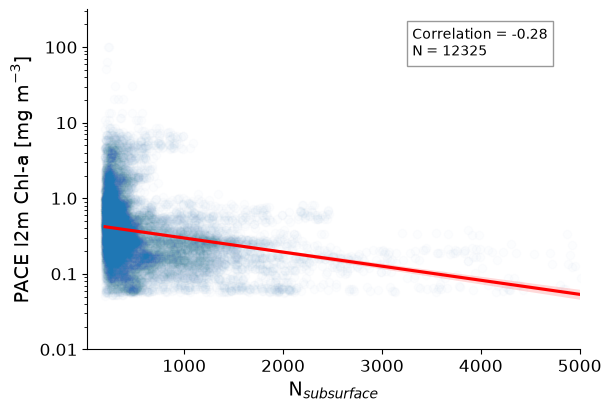

count    12325.000000
mean       611.334686
std        666.625307
min        200.000000
25%        263.000000
50%        376.000000
75%        682.000000
max       8157.000000
Name: N_subsurface, dtype: float64


In [19]:
""" N_subsurface Scatter Plot """

import matplotlib.ticker as ticker

import seaborn as sns
fig, ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans", # or Arial
    "font.size": 10,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

sns.regplot(
    data=matchup_df_filtered,
    x="N_subsurface",
    y="log_chl_a",
    scatter_kws={"alpha":0.01},
    line_kws={"color":"red"},
    truncate=True
)

ax.set_xlabel(r'N$_{subsurface}$')
ax.set_ylabel("PACE l2m Chl-a [mg m$^{-3}$]")

# Set axis ticks in log space, but label them as real values
tick_values = np.array([0.01, 0.1, 1, 10, 100])
tick_positions = np.log10(tick_values)

# ax.set_xticks(tick_positions)
ax.set_yticks(tick_positions)

# ax.set_xticklabels(["0.01", "0.1", "1.0", "10", "100"])
ax.set_yticklabels(["0.01", "0.1", "1.0", "10", "100"])
plt.ylim([-2, 2.5])
plt.xlim([20, 5000])

x = matchup_df_filtered["N_subsurface"].values
y = matchup_df_filtered["log_chl_a"].values

mask = np.isfinite(x) & np.isfinite(y)

corr, p_value = pearsonr(x[mask], y[mask])
ax.text(
    0.66, 0.95,
    f"Correlation = {corr:.2f}\n"
    f"N = {len(matchup_df_filtered["log_chl_a"])}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

# 2. Set the axis to log scale
# ax.set_xscale("log")

# 3. Turn on the mini lines (minor ticks)
# ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs="auto", numticks=12))
ax.xaxis.set_minor_formatter(ticker.NullFormatter())  # Hides labels on mini lines

# 4. Optional: Draw light gridlines on those mini lines
# plt.grid(True, which="minor", color="lightgray", linestyle="--", linewidth=0.5)
# plt.grid(True, which="major", color="gray", linestyle="-", linewidth=0.8)
minor_values = []
for exponent in [-2, -1, 0, 1, 2]: # Covers decades from 0.01 up to 100
    minor_values.extend([i * (10**exponent) for i in range(2, 10)])

# Convert those real values to log10 positions to match your data
minor_positions = np.log10(minor_values)

# Apply the mini lines to BOTH X and Y axes
# ax.xaxis.set_minor_locator(ticker.FixedLocator(minor_positions))
ax.yaxis.set_minor_locator(ticker.FixedLocator(minor_positions))
# ax.tick_params(axis='x', labelsize=12)
# ax.tick_params(axis='y', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig(
    "FINAL_FIGS/PACEChl_v_NSurface.png",
    dpi=600,
    facecolor="white"
)

plt.show()
# print(np.min(matchup_df_filtered['log_R_sw']))
print(matchup_df_filtered['N_subsurface'].describe())

# TIME SERIES

In [20]:

""" 

Open ALL LiDAR segment data

"""
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
segment_vars = gpd.read_parquet("data.FIXEDBINS_1ksegment_vars")



# full coast
# aoi = [
#     [-77.763421055,33.9303851179],[-77.9389743439,33.9691318157],[-77.838130419,34.2068829258],[-77.7806855934,34.2792702972],[-77.6836822968,34.4051947195],[-77.5714627967,34.4649421659],[-77.4442831351,34.5396831298],[-77.2735031984,34.6169609139],[-77.1721106123,34.6724204439],[-76.9868277318,34.7276925566],[-76.829618015,34.7547738305],[-76.6785167259,34.7515431793],[-76.4649412172,34.7280983903],[-76.5954128458,34.5561174476],[-76.8120791459,34.5860554106],[-77.0424071093,34.5535869849],[-77.280873547,34.4423062139],[-77.4544150783,34.356834568],[-77.5812472544,34.2746005606],[-77.7252525255,34.0903854578],[-77.763421055,33.9303851179]
# ]

# north tip
aoi = [[-77.1483718719,34.447524639],[-77.2470211522,34.5916562867],[-77.1673921262,34.6554073709],[-77.0543313457,34.700136295],[-76.888525937,34.7420458357],[-76.7091137311,34.7420458357],[-76.4860280952,34.6915052234],[-76.5117237271,34.4574477966],[-77.1483718719,34.447524639]]


points = Polygon(aoi)

segment_vars = segment_vars[segment_vars.geometry.intersects(points)]

segment_vars["log_R_sw"] = np.log10(segment_vars["R_sw"])
segment_vars["D75/D25"] = segment_vars["D75"] / segment_vars["D25"]

# Limit to Type B/C Ocean

type_a = segment_vars.loc[segment_vars["N_subsurface"] < 200]
segment_vars = segment_vars.loc[segment_vars["N_subsurface"] >= 200]

### import rf_A here:
segment_vars["pred_log_chl_a"] = rf_trimmed.predict(
    segment_vars[features_trimmed]
)

segment_vars["pred_chl_a"] = 10 ** segment_vars["pred_log_chl_a"]



# sort by time, group by hour
segment_vars = segment_vars.sort_values(by="time")


# Create hourly bins
segment_vars["hour"] = segment_vars["time"].dt.floor("h")

# Group by hour and calculate mean, min, max for predicted Chl-a
hourly_lidar_stats = (
    segment_vars.groupby("hour")["pred_chl_a"]
    .agg(["mean", "min", "max", "count"])
)

# Calculate positive and negative errors
hourly_lidar_stats["pos_error"] = (
    hourly_lidar_stats["max"] - hourly_lidar_stats["mean"]
)

hourly_lidar_stats["neg_error"] = (
    hourly_lidar_stats["mean"] - hourly_lidar_stats["min"]
)

MIN_SEGMENTS = 3   # pick a threshold that makes sense for your data density
hourly_lidar_stats = hourly_lidar_stats[hourly_lidar_stats["count"] >= MIN_SEGMENTS]
hourly_lidar_stats.head()

,mean,min,max,count,pos_error,neg_error
hour,,,,,,
2024-06-29 17:00:00,0.589266,0.169046,2.173647,167,1.584381,0.420220
2024-07-23 04:00:00,0.212454,0.193534,0.239913,4,0.027459,0.018920
2024-07-28 15:00:00,1.056671,0.452667,3.053010,117,1.996339,0.604004
2024-08-30 14:00:00,2.778255,1.938979,3.983969,9,1.205715,0.839275
2024-09-28 12:00:00,2.548707,0.713153,4.986465,36,2.437759,1.835554


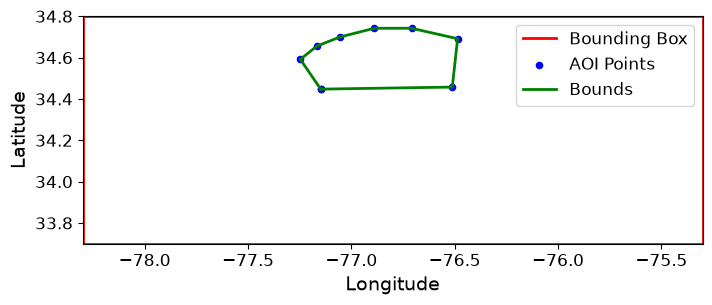

In [21]:
""" 

Create bounding box

"""



LAT_MIN = 33.70
LAT_MAX = 34.80
LON_MIN = -78.30
LON_MAX = -75.30

points = Polygon(aoi)
# boundary_shape = points.convex_hull


# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot bounding box
bbox_x = [LON_MIN, LON_MAX, LON_MAX, LON_MIN, LON_MIN]
bbox_y = [LAT_MIN, LAT_MIN, LAT_MAX, LAT_MAX, LAT_MIN]
ax.plot(bbox_x, bbox_y, color="red", linewidth=2, label="Bounding Box")

x, y = zip(*aoi)
ax.scatter(x, y, color="blue", s=20, label="AOI Points")

hx, hy = points.exterior.xy
ax.plot(hx, hy, color="green", linewidth=2, label="Bounds")

# Formatting
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
ax.set_aspect("equal")

plt.show()

In [22]:
""" 

Grid L2m data

"""

# Via: https://nasa.github.io/oceandata-notebooks/notebooks/oci/subsetting_with_harmony-py.html
from aux_fx import grid_data

In [23]:
""" 

DOWNLOAD PACE DATA. with my 8 threads this was quicker, plus i had to keep redoing plots

"""


# import earthaccess as ea

# import xarray as xr


# ea.login()
# # ea.login(strategy='interactive', persist=True)

# LAT_MIN = 33.70
# LAT_MAX = 34.80
# LON_MIN = -78.30
# LON_MAX = -75.30

# START_DATE = "2025-11-01"
# END_DATE = "2025-11-30"

# results = ea.search_data(
#     short_name="PACE_OCI_L2_BGC",
#     bounding_box=(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX),
#     temporal=(START_DATE, END_DATE),
#     count=False
# )
# dfs = []

# import earthaccess as ea
# import xarray as xr
# import pandas as pd
# import geopandas as gpd
# from shapely.geometry import Polygon
# from concurrent.futures import ThreadPoolExecutor, as_completed

# ea.login()

# LAT_MIN, LAT_MAX = 33.70, 34.80
# LON_MIN, LON_MAX = -78.30, -75.30
# START_DATE, END_DATE = "2025-01-01", "2025-12-31"

# results = ea.search_data(
#     short_name="PACE_OCI_L2_BGC",
#     bounding_box=(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX),
#     temporal=(START_DATE, END_DATE),
#     count=False
# )

# # Download locally instead of streaming — much fewer, larger reads
# files = ea.download(results, local_path="./pace_downloads")

# def process_file(args):
#     fpath, result = args
#     try:
#         with xr.open_dataset(fpath, group="geophysical_data") as data, \
#              xr.open_dataset(fpath, group="navigation_data") as nav:

#             lat = nav["latitude"].values
#             lon = nav["longitude"].values
#             chl = data["chlor_a"].values  # pull to numpy immediately

#         mask = (
#             (lat >= LAT_MIN) & (lat <= LAT_MAX) &
#             (lon >= LON_MIN) & (lon <= LON_MAX) &
#             ~pd.isna(chl)
#         )
#         if not mask.any():
#             return None

#         df = pd.DataFrame({
#             "chlor_a": chl[mask],
#             "latitude": lat[mask],
#             "longitude": lon[mask],
#         })
#         df["swath_time"] = pd.to_datetime(
#             result["umm"]["TemporalExtent"]["RangeDateTime"]["BeginningDateTime"]
#         )
#         return df
#     except Exception as e:
#         print(f"Skipping {fpath}: {e}")
#         return None

# dfs = []
# with ThreadPoolExecutor(max_workers=8) as ex:
#     futures = [ex.submit(process_file, (f, r)) for f, r in zip(files, results)]
#     for fut in as_completed(futures):
#         result = fut.result()
#         if result is not None:
#             dfs.append(result)

# df = pd.concat(dfs, ignore_index=True)
# chl_a_gdf = gpd.GeoDataFrame(
#     df,
#     geometry=gpd.points_from_xy(df.longitude, df.latitude),
#     crs="EPSG:4326",
# )
# chl_a_gdf

# chl_a_gdf.to_parquet("2025PACEDATA", index=False)

' \n\nDOWNLOAD PACE DATA. with my 8 threads this was quicker, plus i had to keep redoing plots\n\n'

In [24]:
chl_a_gdf = gpd.read_parquet("2025PACEDATA")

chl_a_gdf = chl_a_gdf.sort_values("swath_time")

# aoi = [
#     [-77.763421055,33.9303851179],[-77.9389743439,33.9691318157],[-77.838130419,34.2068829258],[-77.7806855934,34.2792702972],[-77.6836822968,34.4051947195],[-77.5714627967,34.4649421659],[-77.4442831351,34.5396831298],[-77.2735031984,34.6169609139],[-77.1721106123,34.6724204439],[-76.9868277318,34.7276925566],[-76.829618015,34.7547738305],[-76.6785167259,34.7515431793],[-76.4649412172,34.7280983903],[-76.5954128458,34.5561174476],[-76.8120791459,34.5860554106],[-77.0424071093,34.5535869849],[-77.280873547,34.4423062139],[-77.4544150783,34.356834568],[-77.5812472544,34.2746005606],[-77.7252525255,34.0903854578],[-77.763421055,33.9303851179]
# ]

points = Polygon(aoi)

chl_a_gdf = chl_a_gdf[chl_a_gdf.geometry.intersects(points)]

# hourly_PACE_gdf = chl_a_gdf.groupby("hour").mean(numeric_only=True)
# hourly_PACE_gdf
# swath_area_avg_PACE_gdf = chl_a_gdf.groupby("swath_time").mean(numeric_only=True)
chl_a_gdf["swath_hour"] = chl_a_gdf["swath_time"].dt.floor("h")

swath_area_stats = (
    chl_a_gdf.groupby("swath_hour")["chlor_a"]
    .agg(["mean", "min", "max", "count"])
)

swath_area_stats["pos_error"] = swath_area_stats["max"] - swath_area_stats["mean"]
swath_area_stats["neg_error"] = swath_area_stats["mean"] - swath_area_stats["min"]

swath_area_stats

,mean,min,max,count,pos_error,neg_error
swath_hour,,,,,,
2025-01-01 17:00:00+00:00,1.887075,0.744056,8.567539,386,6.680464,1.143020
2025-01-04 17:00:00+00:00,1.400198,0.451501,8.591828,491,7.191631,0.948696
2025-01-05 17:00:00+00:00,1.255336,0.427216,11.051987,1160,9.796651,0.828120
2025-01-07 17:00:00+00:00,2.056320,0.895400,7.517920,603,5.461600,1.160920
2025-01-08 17:00:00+00:00,1.434375,0.218753,6.087259,1098,4.652884,1.215621
...,...,...,...,...,...,...
2025-12-27 18:00:00+00:00,1.462815,0.378384,10.271497,598,8.808682,1.084430
2025-12-28 17:00:00+00:00,1.113037,0.411375,12.107758,387,10.994721,0.701661
2025-12-29 17:00:00+00:00,1.385256,0.446363,6.269094,671,4.883838,0.938893


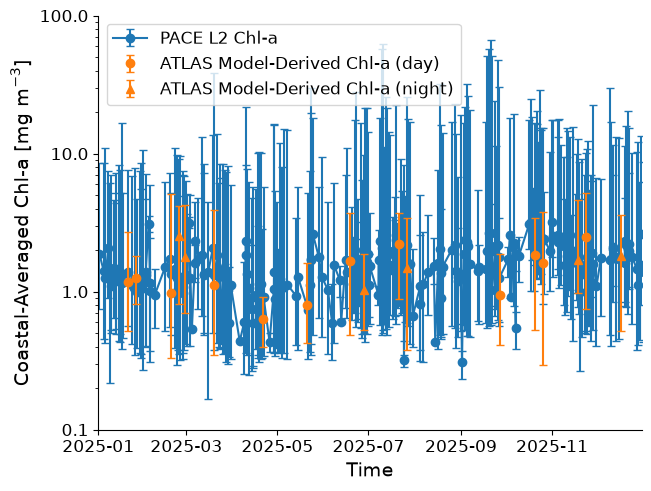

In [25]:
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

fig, ax = plt.subplots(1, 1, constrained_layout=True)

# PACE mean with min/max error bars
ax.errorbar(
    swath_area_stats.index,
    swath_area_stats["mean"],
    yerr=[
        swath_area_stats["neg_error"],
        swath_area_stats["pos_error"],
    ],
    fmt="o-",
    capsize=3,
    label="PACE L2 Chl-a",
    color="tab:blue",
    ecolor="tab:blue",
    zorder=1
)

# ATLAS model

# ATLAS model - split day/night by hour
day_mask = (hourly_lidar_stats.index.hour >= 6) & (hourly_lidar_stats.index.hour < 20)
night_mask = ~day_mask
# ax.errorbar(
#     hourly_lidar_stats.index,
#     hourly_lidar_stats["mean"],
#     yerr=[
#         hourly_lidar_stats["neg_error"],
#         hourly_lidar_stats["pos_error"],
#     ],
#     fmt="o-",
#     capsize=3,
#     color="tab:orange",
#     ecolor="tab:orange",
#     label="ATLAS Model-Derived Chl-a",
#     zorder= 2
# )
ax.errorbar(
    hourly_lidar_stats.index[day_mask],
    hourly_lidar_stats["mean"][day_mask],
    yerr=[
        hourly_lidar_stats["neg_error"][day_mask],
        hourly_lidar_stats["pos_error"][day_mask],
    ],
    fmt="o",
    capsize=3,
    color="tab:orange",
    ecolor="tab:orange",
    label="ATLAS Model-Derived Chl-a (day)",
    zorder=2
)

ax.errorbar(
    hourly_lidar_stats.index[night_mask],
    hourly_lidar_stats["mean"][night_mask],
    yerr=[
        hourly_lidar_stats["neg_error"][night_mask],
        hourly_lidar_stats["pos_error"][night_mask],
    ],
    fmt="^",
    capsize=3,
    color="tab:orange",
    ecolor="tab:orange",
    label="ATLAS Model-Derived Chl-a (night)",
    zorder=2
)


ax.set_yscale("log")
ax.set_ylim([0.1, 100])

ax.set_ylabel("Coastal-Averaged Chl-a [mg m$^{-3}$]")
ax.set_xlabel("Time")

pSTART_DATE = "2025-01-01"
pEND_DATE = "2025-12-31"
ax.set_xlim(
    pd.Timestamp(pSTART_DATE),
    pd.Timestamp(pEND_DATE),
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_yticks([0.1, 1, 10, 100])
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax.legend()

fig.canvas.draw()

bbox = fig.get_tightbbox(fig.canvas.get_renderer())

# fig.savefig(
#     "FINAL_FIGS/ChlvCHL_DIFFCM.png",
#     dpi=600,
#     bbox_inches=bbox,
#     facecolor="white"
# )


fig.savefig(
    "FINAL_FIGS/ScatterTimeSeries.png",
    dpi=600,
    bbox_inches=bbox,
    facecolor="white"
)

plt.show()

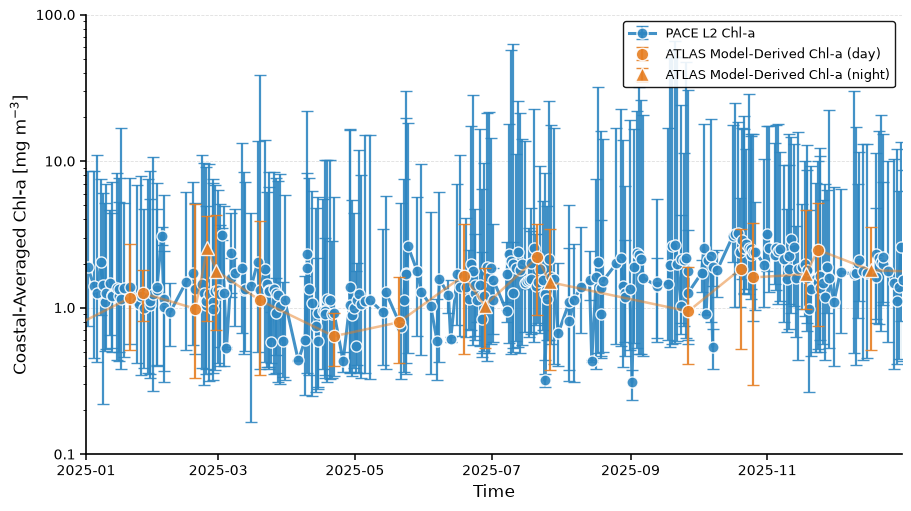

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

fig, ax = plt.subplots(1, 1, figsize=(9, 5), constrained_layout=True)

# PACE mean with min/max error bars
ax.errorbar(
    swath_area_stats.index,
    swath_area_stats["mean"],
    yerr=[
        swath_area_stats["neg_error"],
        swath_area_stats["pos_error"],
    ],
    fmt="o-",
    markersize=8,
    markeredgecolor="white",
    markeredgewidth=1,
    linewidth=2.2,
    capsize=4,
    capthick=1.8,
    elinewidth=1.6,
    alpha=0.9,
    label="PACE L2 Chl-a",
    color="#2E86C1",
    ecolor="#2E86C1",
    zorder=2,
)

# ATLAS model - split day/night by hour
day_mask = (hourly_lidar_stats.index.hour >= 6) & (hourly_lidar_stats.index.hour < 20)
night_mask = ~day_mask

# faint connecting line underneath both marker sets
ax.plot(
    hourly_lidar_stats.index,
    hourly_lidar_stats["mean"],
    "-",
    color="#E67E22",
    linewidth=1.8,
    alpha=0.5,
    zorder=10,
    label="_nolegend_",
)

# daytime: filled circles
ax.errorbar(
    hourly_lidar_stats.index[day_mask],
    hourly_lidar_stats["mean"][day_mask],
    yerr=[
        hourly_lidar_stats["neg_error"][day_mask],
        hourly_lidar_stats["pos_error"][day_mask],
    ],
    fmt="o",
    markersize=9,
    markeredgecolor="white",
    markeredgewidth=1,
    capsize=4,
    capthick=1.8,
    elinewidth=1.6,
    alpha=0.9,
    color="#E67E22",
    ecolor="#E67E22",
    label="ATLAS Model-Derived Chl-a (day)",
    zorder=10,
)

# nighttime: hollow triangles
ax.errorbar(
    hourly_lidar_stats.index[night_mask],
    hourly_lidar_stats["mean"][night_mask],
    yerr=[
        hourly_lidar_stats["neg_error"][night_mask],
        hourly_lidar_stats["pos_error"][night_mask],
    ],
    fmt="^",
    markersize=10,
    # markerfacecolor="none",
    markeredgecolor="white",
    markeredgewidth=1,
    capsize=4,
    capthick=1.8,
    elinewidth=1.6,
    alpha=0.9,
    color="#E67E22",
    ecolor="#E67E22",
    label="ATLAS Model-Derived Chl-a (night)",
    zorder=10,
)

ax.set_yscale("log")
ax.set_ylim([0.1, 100])

ax.set_ylabel("Coastal-Averaged Chl-a [mg m$^{-3}$]", fontsize=12)
ax.set_xlabel("Time", fontsize=12)

pSTART_DATE = "2025-01-01"
pEND_DATE = "2025-12-31"
ax.set_xlim(
    pd.Timestamp(pSTART_DATE),
    pd.Timestamp(pEND_DATE),
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.grid(True, which="major", axis="y", linestyle="--", linewidth=0.6, alpha=0.4, zorder=0)

ax.set_yticks([0.1, 1, 10, 100])
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax.tick_params(axis="both", which="major", labelsize=10, length=4, width=1.1)

legend = ax.legend(
    frameon=True,
    framealpha=0.9,
    edgecolor="black",
    fontsize=9.5,
    loc="upper right",
)
legend.get_frame().set_facecolor("white")

fig.canvas.draw()

bbox = fig.get_tightbbox(fig.canvas.get_renderer())

fig.savefig(
    "FINAL_FIGS/ScatterTimeSeries.png",
    dpi=600,
    bbox_inches=bbox,
    facecolor="white"
)

plt.show()

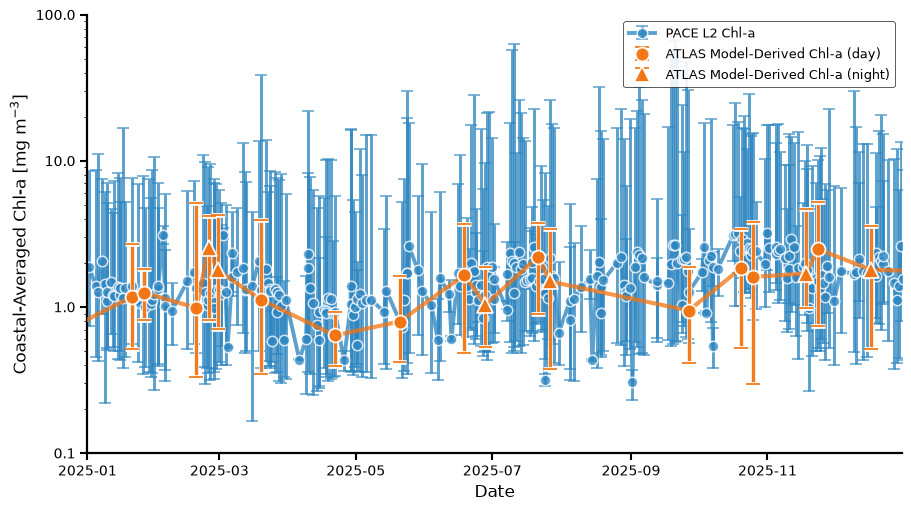

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patheffects as pe

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

fig, ax = plt.subplots(1, 1, figsize=(9, 5), constrained_layout=True)

# PACE mean with min/max error bars
ax.errorbar(
    swath_area_stats.index,
    swath_area_stats["mean"],
    yerr=[
        swath_area_stats["neg_error"],
        swath_area_stats["pos_error"],
    ],
    fmt="o-",
    markersize=7.5,
    markeredgecolor="white",
    markeredgewidth=1.1,
    linewidth=2.8,
    capsize=4.5,
    capthick=2.3,
    elinewidth=2.1,
    alpha=0.78,
    label="PACE L2 Chl-a",
    color="#2E86C1",
    ecolor="#2E86C1",
    zorder=2,
)

# ATLAS model - split day/night by hour
day_mask = (hourly_lidar_stats.index.hour >= 6) & (hourly_lidar_stats.index.hour < 20)
night_mask = ~day_mask

# connecting line, drawn on top
ax.plot(
    hourly_lidar_stats.index,
    hourly_lidar_stats["mean"],
    "-",
    color="#F27411",
    linewidth=3.0,
    alpha=0.75,
    zorder=3,
    label="_nolegend_",
)

# daytime: filled circles, with thin white outline on error bars
day_err = ax.errorbar(
    hourly_lidar_stats.index[day_mask],
    hourly_lidar_stats["mean"][day_mask],
    yerr=[
        hourly_lidar_stats["neg_error"][day_mask],
        hourly_lidar_stats["pos_error"][day_mask],
    ],
    fmt="o",
    markersize=10,
    markeredgecolor="white",
    markeredgewidth=1.3,
    capsize=5,
    capthick=2.7,
    elinewidth=2.4,
    alpha=0.95,
    color="#F27411",
    ecolor="#F27411",
    label="ATLAS Model-Derived Chl-a (day)",
    zorder=4,
)
# apply white stroke outline to error bar lines (caps + whiskers)
for line in day_err.lines[1]:
    line.set_path_effects([pe.Stroke(linewidth=3.4, foreground="white"), pe.Normal()])
for cap in day_err[2]:
    cap.set_path_effects([pe.Stroke(linewidth=3.4, foreground="white"), pe.Normal()])

# nighttime: hollow triangles, with thin white outline on error bars
night_err = ax.errorbar(
    hourly_lidar_stats.index[night_mask],
    hourly_lidar_stats["mean"][night_mask],
    yerr=[
        hourly_lidar_stats["neg_error"][night_mask],
        hourly_lidar_stats["pos_error"][night_mask],
    ],
    fmt="^",
    markersize=11,
    # markerfacecolor="none",
    markeredgecolor="white",
    markeredgewidth=1.3,
    capsize=5,
    capthick=2.7,
    elinewidth=2.4,
    alpha=0.95,
    color="#F27411",
    ecolor="#F27411",
    label="ATLAS Model-Derived Chl-a (night)",
    zorder=4,
)
for line in night_err.lines[1]:
    line.set_path_effects([pe.Stroke(linewidth=3.4, foreground="white"), pe.Normal()])
for cap in night_err[2]:
    cap.set_path_effects([pe.Stroke(linewidth=3.4, foreground="white"), pe.Normal()])

ax.set_yscale("log")
ax.set_ylim([0.1, 100])

ax.set_ylabel("Coastal-Averaged Chl-a [mg m$^{-3}$]", fontsize=12)
ax.set_xlabel("Date", fontsize=12)

pSTART_DATE = "2025-01-01"
pEND_DATE = "2025-12-31"
ax.set_xlim(
    pd.Timestamp(pSTART_DATE),
    pd.Timestamp(pEND_DATE),
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.6)
ax.spines["bottom"].set_linewidth(1.6)

ax.set_yticks([0.1, 1, 10, 100])
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax.tick_params(axis="both", which="major", labelsize=10, length=5, width=1.5)

legend = ax.legend(
    frameon=True,
    framealpha=0.9,
    edgecolor="black",
    fontsize=9.5,
    linewidth = 0.5,
    loc="upper right",
)
legend.get_frame().set_facecolor("white")

fig.canvas.draw()

bbox = fig.get_tightbbox(fig.canvas.get_renderer())

fig.savefig(
    "FINAL_FIGS/ScatterTimeSeries.png",
    dpi=600,
    bbox_inches=bbox,
    facecolor="white"
)

plt.show()